<a href="https://colab.research.google.com/github/Banda-11/student-depression-prediction-ml/blob/main/Pattern_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Student_ID  Age  Gender   Department  CGPA  Sleep_Duration  Study_Hours  \
0        1001   22  Female      Science  3.50             7.3          3.3   
1        1002   20    Male  Engineering  2.72             5.5          7.2   
2        1003   20    Male      Medical  3.01             5.4          2.3   
3        1004   21    Male  Engineering  3.63             8.1          2.0   
4        1005   19    Male         Arts  3.14             6.8          2.6   

   Social_Media_Hours  Physical_Activity  Stress_Level  Depression  
0                 3.4                114             5       False  
1                 6.0                142             2       False  
2                 1.8                137             3       False  
3                 4.6                130             3       False  
4                 4.3                  4             6       False  

-----------------------------------------------------------------------------------------------

<class 'pandas.core

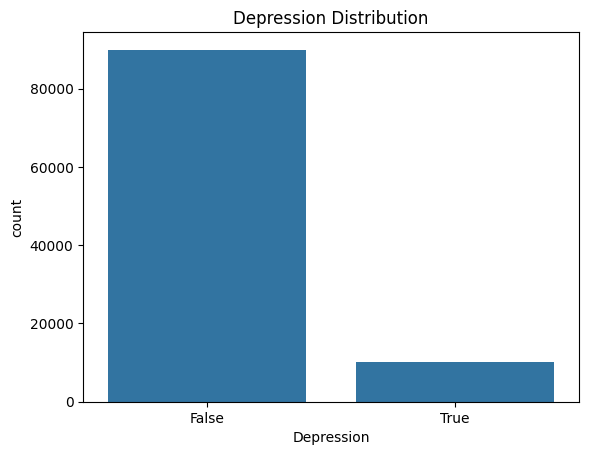


-------------------------------------countplot Of Gender------------------------------------------------



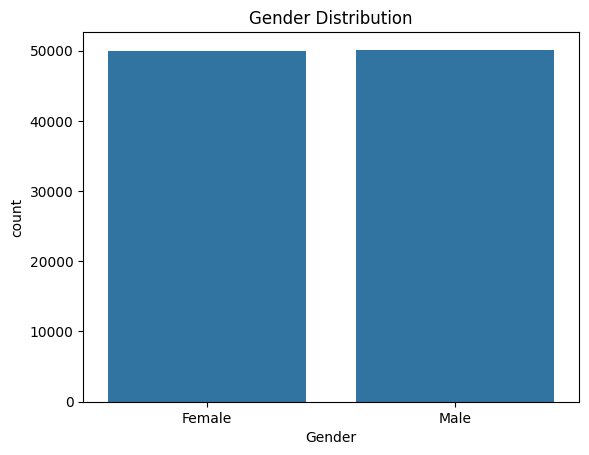


------------------------------------- Countplot Of Department -------------------------------------



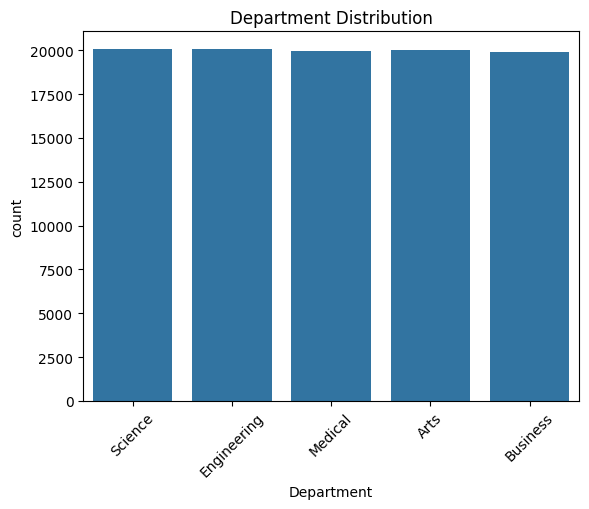


------------------------------------- Correlation Matrix -------------------------------------



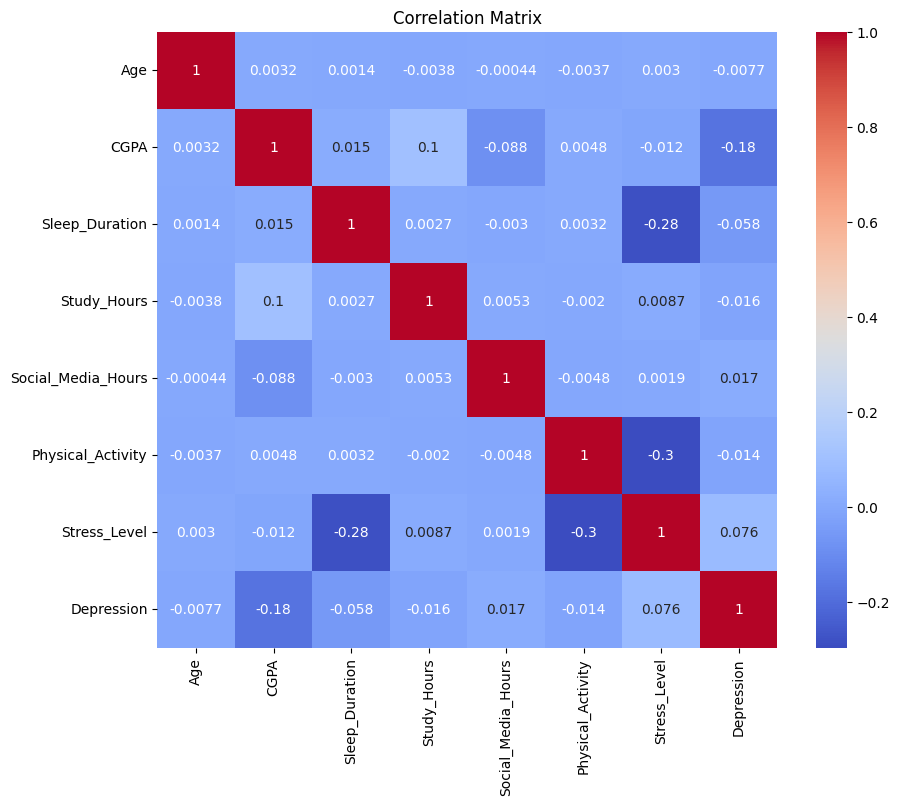


------------------------------------- Feature Distributions -------------------------------------



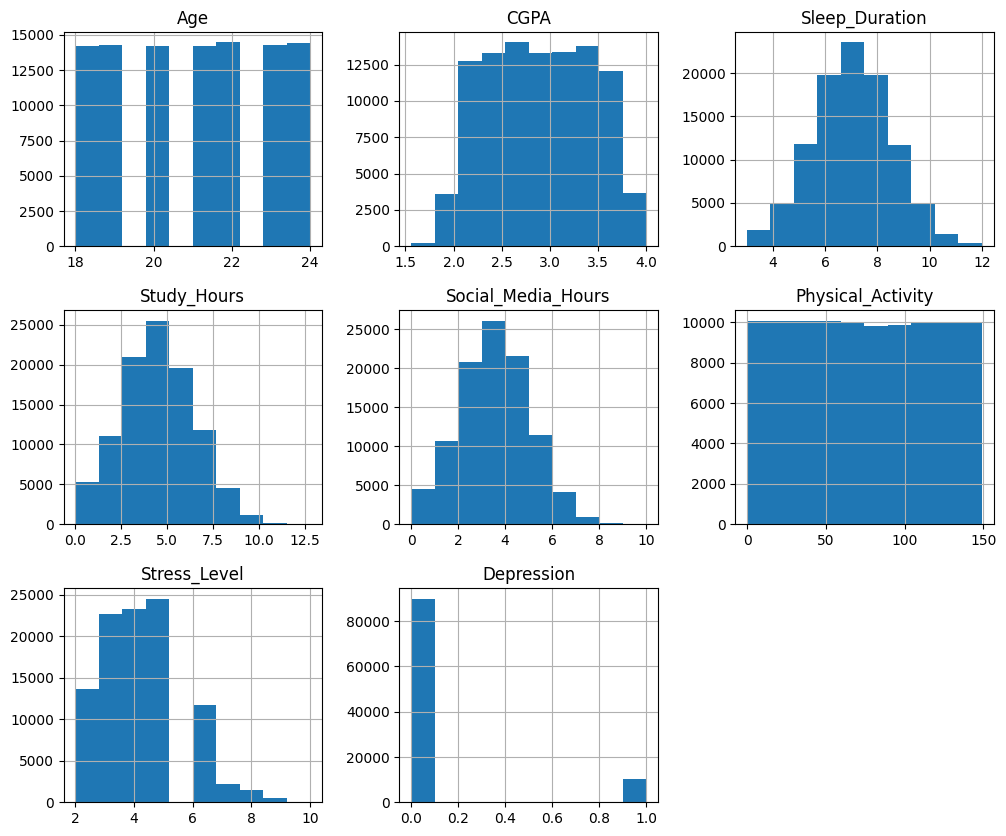


------------------------------------- Insights -------------------------------------

1. The dataset contains no missing values and is clean.
2. The target variable (Depression) is imbalanced, with more non-depressed students.
3. Gender distribution is balanced between male and female students.
4. Department distribution varies, with some departments having more students than others.
5. Correlation analysis shows weak relationships between most features and Depression.
6. Stress_Level has a slight positive correlation, while CGPA has a negative correlation with Depression.
7. Most numerical features are approximately normally distributed, with slight skewness in some variables.


In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
import seaborn as sns
import matplotlib.pyplot as plt


url = "https://drive.google.com/uc?id=1xKYQ1Y7dWoPFz9HRKCIdu-TeURfiqHtj"
data = pd.read_csv(url)

print(data.head())

print("\n-----------------------------------------------------------------------------------------------\n")
data.info()

print("\n-----------------------------------------------------------------------------------------------\n")
data.describe()

print("\n-------------------------------->> Drop useless column >>--------------------------------------------\n")
data.drop("Student_ID", axis=1, inplace=True)

print("\n--------------------------------Check missing values--------------------------------------------\n")
print(data.isnull().sum())

print("\n--------------------------------ReCheck Resault-------------------------------------------------\n")
print(data.head())

print("\n-------------------------------------countplot Of Depression------------------------------------------------\n")
sns.countplot(x='Depression', data=data)
plt.title("Depression Distribution")
plt.show()

print("\n-------------------------------------countplot Of Gender------------------------------------------------\n")
sns.countplot(x='Gender', data=data)
plt.title("Gender Distribution")
plt.show()

print("\n------------------------------------- Countplot Of Department -------------------------------------\n")
sns.countplot(x='Department', data=data)
plt.title("Department Distribution")
plt.xticks(rotation=45)
plt.show()

print("\n------------------------------------- Correlation Matrix -------------------------------------\n")

data['Depression'] = data['Depression'].astype(int)

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

print("\n------------------------------------- Feature Distributions -------------------------------------\n")

data.hist(figsize=(12,10))
plt.show()

print("\n------------------------------------- Insights -------------------------------------\n")

print("1. The dataset contains no missing values and is clean.")
print("2. The target variable (Depression) is imbalanced, with more non-depressed students.")
print("3. Gender distribution is balanced between male and female students.")
print("4. Department distribution varies, with some departments having more students than others.")
print("5. Correlation analysis shows weak relationships between most features and Depression.")
print("6. Stress_Level has a slight positive correlation, while CGPA has a negative correlation with Depression.")
print("7. Most numerical features are approximately normally distributed, with slight skewness in some variables.")

In [ ]:
from sklearn.preprocessing import LabelEncoder
print("\n---------------- ENCODING ----------------\n")

data_encoded = data.copy()

le = LabelEncoder()
data_encoded['Gender'] = le.fit_transform(data_encoded['Gender'])

data_encoded = pd.get_dummies(data_encoded, columns=['Department'], drop_first=True)

data_encoded['Depression'] = data_encoded['Depression'].astype(int)

bool_cols = data_encoded.select_dtypes(include='bool').columns
data_encoded[bool_cols] = data_encoded[bool_cols].astype(int)

print(data_encoded.head())


---------------- ENCODING ----------------

   Age  Gender  CGPA  Sleep_Duration  Study_Hours  Social_Media_Hours  \
0   22       0  3.50             7.3          3.3                 3.4   
1   20       1  2.72             5.5          7.2                 6.0   
2   20       1  3.01             5.4          2.3                 1.8   
3   21       1  3.63             8.1          2.0                 4.6   
4   19       1  3.14             6.8          2.6                 4.3   

   Physical_Activity  Stress_Level  Depression  Department_Business  \
0                114             5           0                    0   
1                142             2           0                    0   
2                137             3           0                    0   
3                130             3           0                    0   
4                  4             6           0                    0   

   Department_Engineering  Department_Medical  Department_Science  
0                    

In [ ]:
print("\n------------------------------------- Feature Selection -------------------------------------\n")

from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd

X = data_encoded.drop('Depression', axis=1)
y = data_encoded['Depression']

k = 5
selector = SelectKBest(score_func=f_classif, k=k)

X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:\n", list(selected_features))

X = pd.DataFrame(X_new, columns=selected_features)


------------------------------------- Feature Selection -------------------------------------

Selected Features:
 ['CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Stress_Level']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


rt_old = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rt_old.fit(X_train, y_train)

y_predict_old = rt_old.predict(X_test)

print(classification_report(y_test, y_predict_old))
print("Accuracy:", accuracy_score(y_test, y_predict_old))
print("Precision:", precision_score(y_test, y_predict_old, average='weighted'))
print("Recall:", recall_score(y_test, y_predict_old, average='weighted'))
print("F1 Score:", f1_score(y_test, y_predict_old, average='weighted'))



smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
rt = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rt.fit(X_train_res, y_train_res)


              precision    recall  f1-score   support

           0       0.90      0.99      0.95     17995
           1       0.31      0.03      0.05      2005

    accuracy                           0.90     20000
   macro avg       0.60      0.51      0.50     20000
weighted avg       0.84      0.90      0.86     20000

Accuracy: 0.89645
Precision: 0.8420636230301523
Recall: 0.89645
F1 Score: 0.8553654084686777


RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_predict = rt.predict(X_test)

print(classification_report(y_test, y_predict))
print("Accuracy:", accuracy_score(y_test, y_predict))
print("Precision:", precision_score(y_test, y_predict, average='weighted'))
print("Recall:", recall_score(y_test, y_predict, average='weighted'))
print("F1 Score:", f1_score(y_test, y_predict, average='weighted'))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93     17995
           1       0.24      0.11      0.15      2005

    accuracy                           0.87     20000
   macro avg       0.57      0.54      0.54     20000
weighted avg       0.84      0.87      0.85     20000

Accuracy: 0.87465
Precision: 0.8397375415791317
Recall: 0.87465
F1 Score: 0.8543289698614707


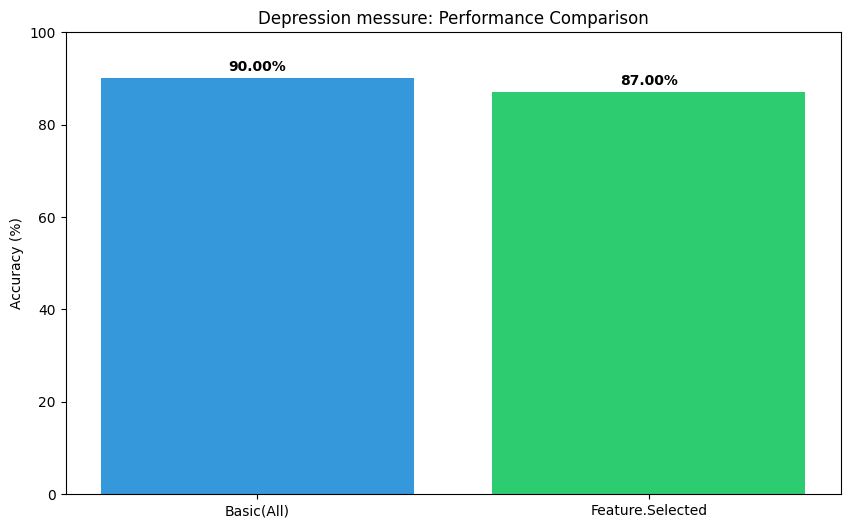

In [ ]:
labels = ['Basic(All)', 'Feature.Selected']
accuracies = [90, 87]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, accuracies, color=['#3498db', '#2ecc71'])
plt.title('Depression messure: Performance Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.62875

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.62      0.75     17995
           1       0.16      0.66      0.26      2005

    accuracy                           0.63     20000
   macro avg       0.55      0.64      0.51     20000
weighted avg       0.87      0.63      0.70     20000


Confusion Matrix:
 [[11246  6749]
 [  676  1329]]


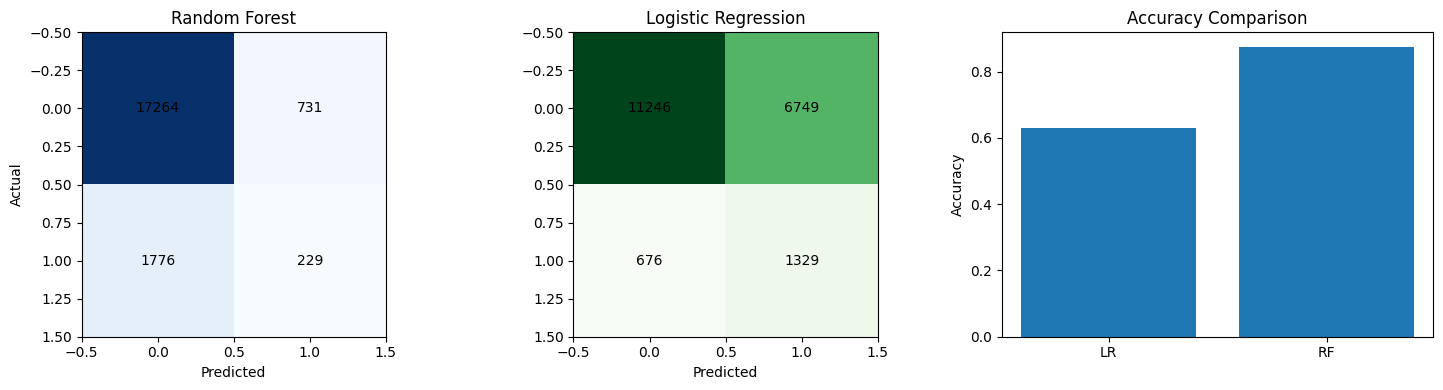

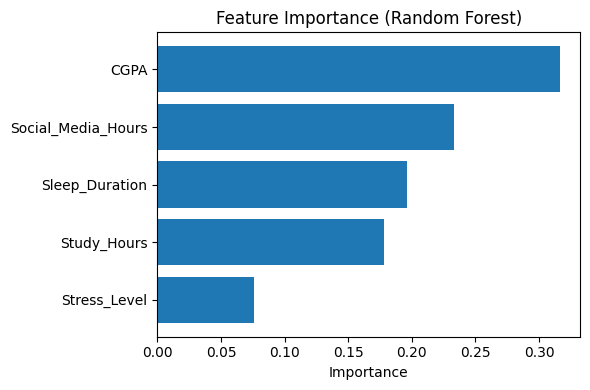

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score

cm_rf = confusion_matrix(y_test, y_predict)
cm_lr = confusion_matrix(y_test_basic, y_pred)

acc_rf = accuracy_score(y_test, y_predict)
acc_lr = accuracy_score(y_test_basic, y_pred)

importances = rt.feature_importances_
indices = np.argsort(importances)

feat_names = [selected_features[i] for i in indices]
feat_vals = importances[indices]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(cm_rf, cmap='Blues')
axes[0].set_title("Random Forest")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        axes[0].text(j, i, cm_rf[i, j], ha='center', va='center')

axes[1].imshow(cm_lr, cmap='Greens')
axes[1].set_title("Logistic Regression")
axes[1].set_xlabel("Predicted")

for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        axes[1].text(j, i, cm_lr[i, j], ha='center', va='center')

axes[2].bar(['LR', 'RF'], [acc_lr, acc_rf])
axes[2].set_title("Accuracy Comparison")
axes[2].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.barh(feat_names, feat_vals)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()